# PCA and DBSCAN Analysis of Migraine Lifestyle Patterns

This notebook follows the supervisor recommendation to explore clustering-style analysis. PCA is used as a dimensionality-reduction technique for visual inspection, while DBSCAN is used as a density-based clustering method to test whether the lifestyle features naturally form meaningful groups.

## 1. Import required libraries

Additional imports are used here for dimensionality reduction and clustering.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score


## 2. Load the dataset

In [2]:
data_path = Path('/Users/cioran/Documents/migraine-prediction-project/data/migraine_dataset.csv')
print('Loading dataset from:', data_path)
df = pd.read_csv(data_path)
df.head()


Loading dataset from: /Users/cioran/Documents/migraine-prediction-project/data/migraine_dataset.csv


,user_id,date,sleep_hours,mood_level,stress_level,hydration_level,screen_time,migraine_occurrence,migraine_severity
0,1,1/15/2024,7.8,3,2,2,4.7,1,1
1,1,1/16/2024,6.6,4,1,2,3.2,1,1
2,1,1/17/2024,8.5,4,2,2,4.7,1,2
3,1,1/18/2024,7.5,3,2,3,3.8,1,3
4,1,1/19/2024,9.0,3,2,1,6.8,1,2


## 3. Create the improved feature set

In [3]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['sleep_stress_interaction'] = df['sleep_hours'] * df['stress_level']
df['screen_stress_interaction'] = df['screen_time'] * df['stress_level']
df['hydration_stress_interaction'] = df['hydration_level'] * df['stress_level']

features = [
    'sleep_hours',
    'mood_level',
    'stress_level',
    'hydration_level',
    'screen_time',
    'day_of_week',
    'month',
    'sleep_stress_interaction',
    'screen_stress_interaction',
    'hydration_stress_interaction',
]

X = df[features]
print('Feature matrix shape:', X.shape)
print('Severity distribution:')
print(df['migraine_severity'].value_counts().sort_index())


Feature matrix shape: (11879, 10)
Severity distribution:
migraine_severity
0    6119
1    2493
2    2874
3     393
Name: count, dtype: int64


## 4. Standardise the features

PCA and DBSCAN are both sensitive to feature scaling, so the improved feature set is standardised first.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled feature matrix shape:', X_scaled.shape)

Scaled feature matrix shape: (11879, 10)


## 5. Apply PCA

PCA reduces the feature space to two components so that the records can be visualised more easily.

In [5]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
print('Explained variance ratio:', explained_variance)
print('Total explained variance:', explained_variance.sum())

Explained variance ratio: [0.35422249 0.15747821]
Total explained variance: 0.5117007006494293


## 6. Plot PCA coloured by migraine occurrence

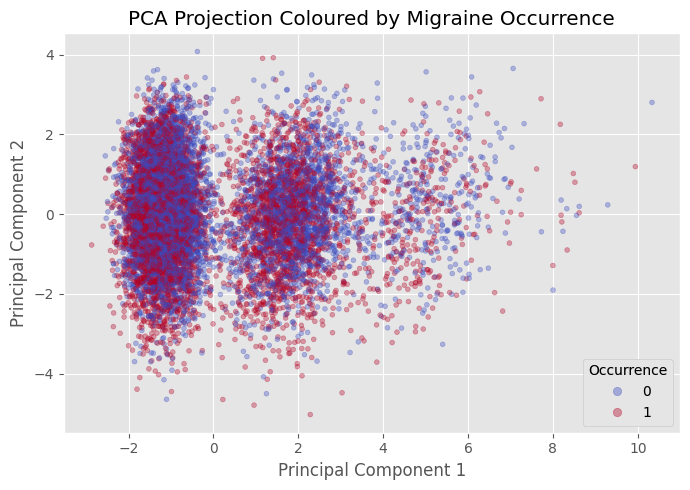

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=df['migraine_occurrence'],
    cmap='coolwarm',
    alpha=0.35,
    s=12,
)
ax.set_title('PCA Projection Coloured by Migraine Occurrence')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
legend = ax.legend(*scatter.legend_elements(), title='Occurrence')
ax.add_artist(legend)
plt.tight_layout()
plt.show()

## 7. Plot PCA coloured by migraine severity

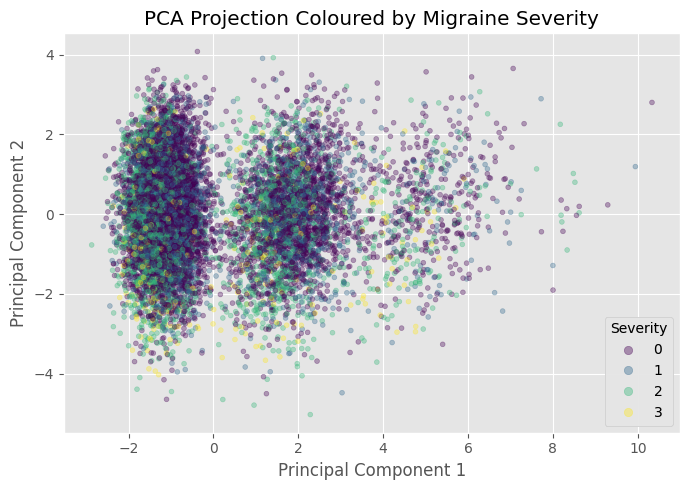

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=df['migraine_severity'],
    cmap='viridis',
    alpha=0.35,
    s=12,
)
ax.set_title('PCA Projection Coloured by Migraine Severity')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
legend = ax.legend(*scatter.legend_elements(), title='Severity')
ax.add_artist(legend)
plt.tight_layout()
plt.show()

## 8. Test DBSCAN over a small range of parameters

DBSCAN is sensitive to the `eps` parameter. A small parameter sweep is used to inspect whether any stable cluster structure appears.

In [8]:

dbscan_results = []

for eps in [0.5, 0.7, 0.9, 1.1, 1.3]:
    dbscan = DBSCAN(eps=eps, min_samples=20)
    cluster_labels = dbscan.fit_predict(X_scaled)

    cluster_count = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    noise_ratio = (cluster_labels == -1).mean()

    silhouette = np.nan
    if cluster_count > 1 and (cluster_labels != -1).sum() > 1:
        non_noise_labels = cluster_labels[cluster_labels != -1]
        non_noise_points = X_scaled[cluster_labels != -1]
        if len(set(non_noise_labels)) > 1:
            silhouette = silhouette_score(non_noise_points, non_noise_labels)

    dbscan_results.append({
        'eps': eps,
        'clusters_found': cluster_count,
        'noise_ratio': noise_ratio,
        'silhouette_score': silhouette,
        'ARI_vs_occurrence': adjusted_rand_score(df['migraine_occurrence'], cluster_labels),
        'ARI_vs_severity': adjusted_rand_score(df['migraine_severity'], cluster_labels),
    })

dbscan_df = pd.DataFrame(dbscan_results)
dbscan_df


,eps,clusters_found,noise_ratio,silhouette_score,ARI_vs_occurrence,ARI_vs_severity
0,0.5,0,1.000000,NaN,0.000000,0.000000
1,0.7,7,0.863793,-0.017312,0.000371,0.000709
2,0.9,16,0.524707,0.020888,0.001565,-0.004093
3,1.1,20,0.296321,0.043194,0.003050,0.000555
4,1.3,13,0.168196,0.083863,0.000920,0.001681


## 9. Review the DBSCAN summary table

Adjusted Rand Index (ARI) is included to show whether the discovered clusters align meaningfully with occurrence or severity labels.

In [9]:
dbscan_df

,eps,clusters_found,noise_ratio,silhouette_score,ARI_vs_occurrence,ARI_vs_severity
0,0.5,0,1.000000,NaN,0.000000,0.000000
1,0.7,7,0.863793,-0.017312,0.000371,0.000709
2,0.9,16,0.524707,0.020888,0.001565,-0.004093
3,1.1,20,0.296321,0.043194,0.003050,0.000555
4,1.3,13,0.168196,0.083863,0.000920,0.001681


## 10. Visualise the DBSCAN clustering result for the best silhouette score

This plot is exploratory rather than confirmatory. It helps show whether the clusters appear meaningful in two dimensions.

Best eps by silhouette score: 1.3


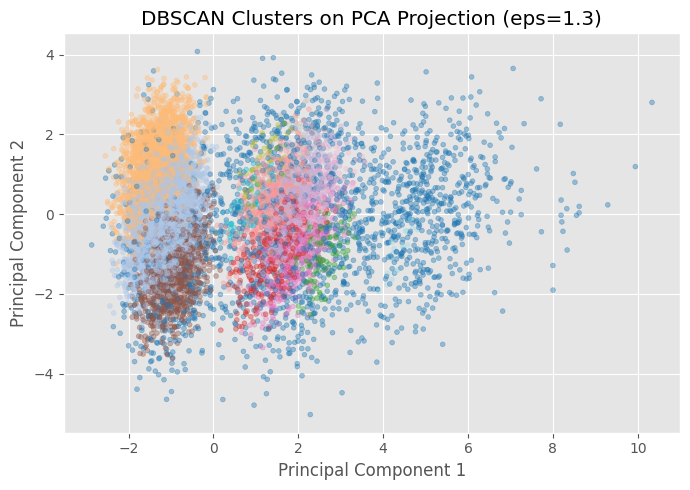

In [10]:
best_row = dbscan_df.sort_values(by='silhouette_score', ascending=False).iloc[0]
best_eps = float(best_row['eps'])
print('Best eps by silhouette score:', best_eps)

best_dbscan = DBSCAN(eps=best_eps, min_samples=20)
best_labels = best_dbscan.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=best_labels,
    cmap='tab20',
    alpha=0.4,
    s=12,
)
ax.set_title(f'DBSCAN Clusters on PCA Projection (eps={best_eps})')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

## 11. Conclusion

PCA and DBSCAN provide exploratory insight into the feature space. If the PCA plots show substantial overlap and DBSCAN clusters align weakly with the migraine labels, that suggests the records do not separate into strong natural groups using the current features alone. This is still useful, because it supports a careful discussion of why supervised prediction may only achieve moderate performance.